# M2 — Model 4 of 4: EfficientNet-B0 (MobileNet blocks + attention + balanced scaling)

**Project:** Bio-Inspired Medicinal Plant Species Crowd-sourcing Using Goats
**Course:** CSC 3118 — Computer Science Project I
**Dataset:** Jannat, Preety & Mojumdar (2024), *Dataset of Medicinal Plant Leaves:
Hibiscus, Aloe Vera, Moringa, Tulsi, and Neem*, Mendeley Data, doi:10.17632/d297rvr3r6.1
**Data used:** original (raw) photos only, split by leaf group inside this notebook
**Training:** from scratch, no pretrained weights

## The question M2 answers

The collar's M1 model has just decided *the goat is eating*, and the camera has
taken a photo. M2 answers: **which plant is it?** It picks one of five species,
or declines to answer if it isn't confident enough (Step 7).

**This notebook stands alone.** It reads the raw plant folders, makes its own
split, trains, tests and saves its results. It needs no other notebook.

**Before running:** set `DATA_DIR` in the configuration cell.
**Run order:** Kernel → Restart Kernel and Run All Cells.

## Where EfficientNet comes from

EfficientNet (Tan & Le, Google, 2019) asked a simple question: if you have more
computing budget, *how* should you make a network bigger? Deeper (more layers)?
Wider (more filters)? Or feed it bigger photos? Most designs had grown just one
of these. EfficientNet showed that growing **all three together, in a fixed
balance** (called *compound scaling*), gives far more accuracy per weight.

**B0** is the smallest member of the family, the base network the others are
scaled up from. It was found by an automated search for the most accurate
network under a tight computing budget.

## Its building block: MBConv = MobileNetV2 block + two additions

EfficientNet-B0 uses the same **inverted residual** block as MobileNetV2 (expand →
depthwise filter → project, with a skip connection). It adds two things:

### 1. Squeeze-and-excitation: attention over channels

After the depthwise filtering, each block pauses to ask **"which of my channels
matter for this photo?"**

```
feature maps (H x W x C)
   │
   ├── SQUEEZE:  average each channel to one number        -> C numbers
   │             ("how strongly did each pattern fire overall?")
   ├── EXCITE:   two tiny 1x1 layers -> C weights, each 0 to 1
   │             ("for THIS leaf, which patterns are worth listening to?")
   └── SCALE:    multiply every channel by its weight
```

For a neem leaf, channels that respond to serrated edges might be turned up and
channels that respond to smooth margins turned down. It's a form of
**attention** that adds very little arithmetic, because it works on one number
per channel rather than on whole feature maps.

### 2. Swish instead of ReLU, and 5×5 filters in some blocks

**Swish**, x · sigmoid(x), is a smooth version of ReLU. It lets a little
negative signal through, which helps deeper networks train. Some blocks use a
**5×5** depthwise filter instead of 3×3, to see a wider patch of the leaf.

## EfficientNet-B0 at 160 × 160

```
photo (160 x 160 x 3) -> augmentation (training only)
  -> Stem: 3x3 conv, 32 filters, stride 2                        80 x 80
  -> 16 MBConv blocks, in 7 stages:
       expand  kernel  channels  blocks  stride
         1      3x3       16       1       1                      80 x 80
         6      3x3       24       2       2                      40 x 40
         6      5x5       40       2       2                      20 x 20
         6      3x3       80       3       2                      10 x 10
         6      5x5      112       3       1                      10 x 10
         6      5x5      192       4       2                       5 x 5
         6      3x3      320       1       1                       5 x 5
  -> 1x1 conv to 1280 channels -> global average -> dropout -> 5 outputs
```

## What this model tests

It has about **4 million weights**, more than MobileNetV2 (2.3 M) but a third of
ResNet-18 (11.2 M). The head-to-head with MobileNetV2 is the key question: **do
the attention and the smarter design buy enough accuracy to justify the extra
size and slower speed on the collar?**

In [4]:
# =============================================================================
# CONFIGURATION
# =============================================================================
# The folder holding the RAW photos: one subfolder per plant (Aloe Vera,
# Hibiscus, Moringa, Neem, Tulsi). If you point it at the dataset's top folder
# instead, the notebook finds the raw section by itself and ignores augmented.
# Use EXACTLY the same path in all four plant notebooks, so they get the same split.
DATA_DIR = r"C:\Users\OKEDI\Desktop\Dataset of Medicinal Plant Leaves Hibiscus, Aloe Vera, Moringa, Tulsi, and Neem (3)\data\Raw"          # <-- CHANGE THIS

OUT_DIR = "plant_results"             # everything this notebook saves goes here

MODEL_NAME = "EfficientNet-B0"
TAG = "M2_4_EfficientNetB0"

IMG_SIZE = 160          # the same for all four models, so they compare fairly
BATCH_SIZE = 32
EPOCHS = 60             # upper limit; early stopping usually ends sooner
LEARNING_RATE = 1e-3
PATIENCE = 10           # stop after this many epochs with no validation gain
WARMUP_EPOCHS = 10       # early stopping may not end training before this epoch
RANDOM_SEED = 42

# Reject option (Step 7): the model only names a plant when its top
# probability reaches a threshold chosen so that validation accuracy on the
# photos it DOES answer is at least this high.
TARGET_ACCEPTED_ACCURACY = 0.98

# Batch normalisation keeps a running average of each layer's output to use at
# test time. Keras's default (0.99) updates it very slowly, so on a few
# thousand photos validation can look random for the first epochs. 0.9 lets
# the average catch up quickly. The same value is used in all four models.
BN_MOMENTUM = 0.9

# Stochastic depth: during training, each block with a skip connection is
# randomly skipped with a small probability (rising to this value for the last
# block). It's a form of regularisation from the original EfficientNet.
DROP_CONNECT_RATE = 0.2

In [5]:
# =============================================================================
# IMPORTS
# =============================================================================
import os, re, json, time, glob, pathlib, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, top_k_accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image, ImageOps, ImageFilter

keras.utils.set_random_seed(RANDOM_SEED)
tf.get_logger().setLevel("ERROR")

RESULTS_DIR = os.path.join(OUT_DIR, "results")
FIG_DIR = os.path.join(OUT_DIR, "figures")
MODEL_DIR = os.path.join(OUT_DIR, "models")
SPLIT_DIR = os.path.join(OUT_DIR, "splits")
for d in (RESULTS_DIR, FIG_DIR, MODEL_DIR, SPLIT_DIR):
    os.makedirs(d, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 10,
})
MAIN, MUTED, INK = "#2a78d6", "#9aa5b1", "#1f2933"
print("TensorFlow", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU") or "none (CPU)")

TensorFlow 2.21.0 | GPU: none (CPU)


## Step 1 — Prepare the data

### 1a. Find the photos

The notebook lists every image under `DATA_DIR`. The folder each photo sits in
is its plant name. If the dataset's augmented section is also under `DATA_DIR`,
it is left out. Augmented images are edited copies of raw photos, and a copy of
a test photo sitting in training would inflate the score.

In [6]:
# =============================================================================
# 1a. FIND THE RAW PHOTOS
# =============================================================================
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
root = pathlib.Path(DATA_DIR)
if not root.is_dir():
    raise FileNotFoundError(
        f"DATA_DIR does not exist:\n  {root}\n"
        "Open the raw folder in File Explorer, click the address bar, copy the path "
        "and paste it into DATA_DIR in the configuration cell (keep the r before the quote).")


def norm_class(name):
    """'Aloe Vera', 'aloe_vera' and 'Aloe-Vera' all become 'aloe_vera'."""
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")


rows = []
for p in sorted(root.rglob("*")):                      # sorted: same order every run
    if p.is_file() and p.suffix.lower() in IMG_EXT:
        rel = p.relative_to(root).parts
        rows.append({"path": str(p), "rel": "/".join(rel), "class": norm_class(p.parent.name),
                     "section": rel[0] if len(rel) >= 3 else "(top level)"})
df = pd.DataFrame(rows)
if df.empty:
    raise FileNotFoundError(f"No images found under {root}")

sections = sorted(df["section"].unique())
raw_like = [x for x in sections if re.search(r"raw|orig", x, re.I)]
if raw_like:
    left_out = int((~df["section"].isin(raw_like)).sum())
    df = df[df["section"].isin(raw_like)].reset_index(drop=True)
    print(f"Using the raw section {raw_like}; left out {left_out:,} images from {sorted(set(sections) - set(raw_like))}")
elif any(re.search(r"aug", x, re.I) for x in sections):
    raise ValueError("DATA_DIR contains an augmented section but no raw/original one. "
                     "Point DATA_DIR at the raw folder.")

CLASSES = sorted(df["class"].unique())
NUM_CLASSES = len(CLASSES)
if NUM_CLASSES < 2:
    raise ValueError(f"Only {NUM_CLASSES} plant folder found. DATA_DIR is one level too deep: "
                     "point it at the folder that CONTAINS the plant folders.")
print(f"{len(df):,} raw photos, {NUM_CLASSES} plants\n")
print(df["class"].value_counts().sort_index().to_string())

2,607 raw photos, 6 plants

class
1               820
aloe_vera_bg    235
moringa_bg      367
nim_2_bg        720
nim_bg           66
tulsi_bg        399


### 1b. Group photos of the same leaf

People often photograph the same leaf several times in a row. Those shots are
practically identical, and if one lands in training and another in test, the
model is tested on a leaf it has already seen.

So every photo gets a **fingerprint** (a perceptual hash). The photo is blurred
slightly, shrunk to a 17 × 17 grey thumbnail, and for each pixel we record
whether it is brighter than its neighbour, giving 256 yes/no bits. Two shots of
the same leaf differ in only a few bits; two different leaves differ in about
half of them. We compare in 8 orientations, so a rotated or mirrored shot still
matches. Photos whose fingerprints nearly match become one **group**.

In [7]:
# =============================================================================
# 1b. FINGERPRINT AND GROUP
# =============================================================================
HASH_THRESHOLD = 16        # of 256 bits; "the same leaf" if this close or closer
MAX_GROUP_SHARE = 0.05     # safety net: no group may hold more than 5% of a plant


def fingerprints(path):
    """256-bit difference hash in 8 orientations -> (8, 4) uint64."""
    with Image.open(path) as im:
        g = ImageOps.exif_transpose(im).convert("L").resize((64, 64), Image.BILINEAR)
        g = g.filter(ImageFilter.GaussianBlur(1.0)).resize((17, 17), Image.BILINEAR)
        g = np.asarray(g, dtype=np.float32)
    out = []
    for k in range(4):
        for flip in (False, True):
            t = np.fliplr(np.rot90(g, k)) if flip else np.rot90(g, k)
            bits = (t[:16, 1:] > t[:16, :-1]).ravel()
            out.append(np.packbits(bits).view(">u8").astype(np.uint64))
    return np.stack(out)


def popcount64(a):
    if hasattr(np, "bitwise_count"):
        return np.bitwise_count(a)
    a = a - ((a >> np.uint64(1)) & np.uint64(0x5555555555555555))
    a = (a & np.uint64(0x3333333333333333)) + ((a >> np.uint64(2)) & np.uint64(0x3333333333333333))
    a = (a + (a >> np.uint64(4))) & np.uint64(0x0F0F0F0F0F0F0F0F)
    return (a * np.uint64(0x0101010101010101)) >> np.uint64(56)


t0 = time.time()
H, ok = [], []
for p in df["path"]:
    try:
        H.append(fingerprints(p)); ok.append(True)
    except Exception:
        ok.append(False)
if not all(ok):
    print(f"Skipped {ok.count(False)} unreadable files.")
df = df[np.array(ok)].reset_index(drop=True)
H = np.stack(H)

pairs = []
for c in CLASSES:
    idx = np.where(df["class"].values == c)[0]
    for s in range(0, len(idx), 128):
        a = idx[s:s + 128]
        D = popcount64(H[a][:, :, None, :] ^ H[idx][None, None, :, 0, :]).sum(-1).min(1)
        ii, jj = np.where(D <= HASH_THRESHOLD)
        pairs += [(a[i], idx[j], int(D[i, j])) for i, j in zip(ii, jj) if a[i] < idx[j]]


def make_groups(threshold):
    parent = np.arange(len(df))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    for a, b, dist in pairs:
        if dist <= threshold:
            ra, rb = find(a), find(b)
            if ra != rb:
                parent[max(ra, rb)] = min(ra, rb)
    return np.array([f"g{find(i)}" for i in range(len(df))])


class_n = df["class"].value_counts()
threshold_used = HASH_THRESHOLD
while True:
    df["group"] = make_groups(threshold_used)
    gs = df.groupby("group").agg(cls=("class", "first"), n=("path", "size"))
    limit = gs["cls"].map(lambda c: max(10, MAX_GROUP_SHARE * class_n[c]))
    if (gs["n"] <= limit).all() or threshold_used <= 4:
        break
    threshold_used -= 1

print(f"Fingerprinted {len(df):,} photos in {time.time() - t0:.0f}s (threshold {threshold_used} bits)")
print(f"{len(df):,} photos -> {len(gs):,} leaf groups")
print(f"Photos that have a near-identical twin: {int(gs.loc[gs['n'] > 1, 'n'].sum()):,} "
      f"({gs.loc[gs['n'] > 1, 'n'].sum() / len(df):.1%})")
print(f"Largest group: {gs['n'].max()} photos")

Fingerprinted 2,607 photos in 133s (threshold 4 bits)
2,607 photos -> 2,075 leaf groups
Photos that have a near-identical twin: 880 (33.8%)
Largest group: 74 photos


### 1c. Split 70 / 15 / 15 by group

Within each plant, the groups are shuffled with a fixed seed and dealt out until
training holds about 70% of that plant's photos, validation 15% and test 15%. A
group is never divided.

Because the photo list is sorted and the seed is fixed, **every one of the four
plant notebooks produces exactly the same split**, with no shared file needed.
The **split ID** printed below proves it: it must be identical in all four.

In [8]:
# =============================================================================
# 1c. GROUP-AWARE SPLIT (identical in all four notebooks)
# =============================================================================
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15
rng_split = np.random.default_rng(RANDOM_SEED)
split_of = {}
for c in CLASSES:
    g = df[df["class"] == c].groupby("group").size().sort_index()
    total, cum = g.sum(), 0
    for grp in rng_split.permutation(g.index.values):
        frac = cum / total
        split_of[grp] = "train" if frac < TRAIN_FRAC else ("val" if frac < TRAIN_FRAC + VAL_FRAC else "test")
        cum += g[grp]
df["split"] = df["group"].map(split_of)
df["label"] = df["class"].map({c: i for i, c in enumerate(CLASSES)})

assert df.groupby("group")["split"].nunique().max() == 1, "a group was split"
SPLIT_ID = hashlib.sha1("\n".join(sorted(df["rel"] + "|" + df["split"])).encode()).hexdigest()[:10]
df.to_csv(os.path.join(SPLIT_DIR, f"{TAG}_split.csv"), index=False)

tbl = pd.crosstab(df["class"], df["split"])[["train", "val", "test"]]
tbl["total"] = tbl.sum(1)
print(tbl.to_string())
print(f"\nNo leaf group appears in more than one split. Verified.")
print(f"SPLIT ID: {SPLIT_ID}   <- must be the same in all four plant notebooks")

split         train  val  test  total
class                                
1               575  122   123    820
aloe_vera_bg    165   68     2    235
moringa_bg      259   53    55    367
nim_2_bg        505  130    85    720
nim_bg           47   10     9     66
tulsi_bg        280   61    58    399

No leaf group appears in more than one split. Verified.
SPLIT ID: 2ee04fb978   <- must be the same in all four plant notebooks


C:\Users\OKEDI\AppData\Local\Temp\ipykernel_9556\943890921.py:22: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  tbl["total"] = tbl.sum(1)


## Step 2 — The data pipeline

Each photo is read from disk, resized to 160 × 160, and kept in memory after the
first epoch so later epochs are fast. Pixels stay in the 0–255 range here. Each
model rescales them itself, as its first layer.

**Class weights:** if one plant has more photos than another, the model is
tempted to favour it. Weighting makes a mistake on a rarer plant cost more.

In [9]:
# =============================================================================
# PIPELINE
# =============================================================================
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), antialias=True)
    return tf.cast(tf.clip_by_value(img, 0, 255), tf.uint8), label


def make_ds(split, training):
    sub = df[df["split"] == split]
    ds = tf.data.Dataset.from_tensor_slices((sub["path"].values, sub["label"].values))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if len(sub) <= 8000:
        ds = ds.cache()                      # decoded photos kept in memory (uint8)
    if training:
        ds = ds.shuffle(len(sub), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y))
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


ds_tr, ds_va, ds_te = make_ds("train", True), make_ds("val", False), make_ds("test", False)
te_df = df[df["split"] == "test"].reset_index(drop=True)
va_df = df[df["split"] == "val"].reset_index(drop=True)
y_te, y_va = te_df["label"].values, va_df["label"].values

y_tr = df.loc[df["split"] == "train", "label"].values
cw = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_tr)
class_weight = {i: float(w) for i, w in enumerate(cw)}
for c, w in zip(CLASSES, cw):
    print(f"  {c:<14} weight {w:.2f}")

  1              weight 0.53
  aloe_vera_bg   weight 1.85
  moringa_bg     weight 1.18
  nim_2_bg       weight 0.60
  nim_bg         weight 6.49
  tulsi_bg       weight 1.09


## Step 3 — Augmentation, inside the model

These layers change each training photo **randomly, every epoch**: a flip, a
small rotation, a zoom, a shift, a contrast change. Over 60 epochs the model sees
dozens of different versions of every leaf. This is what replaces the dataset's
augmented folder, without its leakage.

Keras switches these layers **off** automatically for validation and test, so
those photos are always judged exactly as they are.

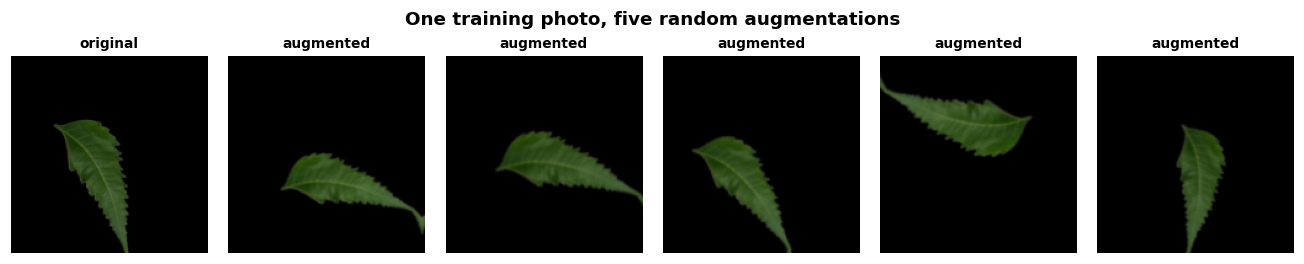

In [10]:
# =============================================================================
# AUGMENTATION (active during training only)
# =============================================================================
augment = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),   # a leaf has no "right way up"
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.10, 0.10),
    layers.RandomContrast(0.15),
], name="augmentation")

sample = next(iter(ds_tr))[0][:1]
fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
axes[0].imshow(sample[0].numpy().astype("uint8")); axes[0].set_title("original", fontsize=9)
for ax in axes[1:]:
    ax.imshow(np.clip(augment(sample, training=True)[0].numpy(), 0, 255).astype("uint8"))
    ax.set_title("augmented", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.suptitle("One training photo, five random augmentations", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "M2_augmentation_examples.png"))
plt.show()

## Step 4 — Build the model

In [11]:
# =============================================================================
# THE ARCHITECTURE
# =============================================================================
def squeeze_excite(x, in_channels, name, ratio=0.25):
    """Channel attention: squeeze each channel to one number, learn a 0-1
    weight per channel, and rescale the feature maps by those weights."""
    channels = x.shape[-1]
    s = layers.GlobalAveragePooling2D(keepdims=True, name=f"{name}_se_squeeze")(x)
    s = layers.Conv2D(max(1, int(in_channels * ratio)), 1, activation="swish", name=f"{name}_se_reduce")(s)
    s = layers.Conv2D(channels, 1, activation="sigmoid", name=f"{name}_se_expand")(s)
    return layers.Multiply(name=f"{name}_se_scale")([x, s])


def mbconv(x, expansion, kernel, out_channels, stride, drop_rate, name):
    """MBConv: expand (1x1) -> depthwise (kxk) -> squeeze-excite -> project (1x1) [+ skip]."""
    in_channels = x.shape[-1]
    y = x
    if expansion != 1:
        y = layers.Conv2D(in_channels * expansion, 1, use_bias=False, name=f"{name}_expand")(y)
        y = layers.BatchNormalization(momentum=BN_MOMENTUM, name=f"{name}_expand_bn")(y)
        y = layers.Activation("swish", name=f"{name}_expand_swish")(y)
    y = layers.DepthwiseConv2D(kernel, strides=stride, padding="same", use_bias=False, name=f"{name}_depthwise")(y)
    y = layers.BatchNormalization(momentum=BN_MOMENTUM, name=f"{name}_depthwise_bn")(y)
    y = layers.Activation("swish", name=f"{name}_depthwise_swish")(y)
    y = squeeze_excite(y, in_channels, name)
    y = layers.Conv2D(out_channels, 1, use_bias=False, name=f"{name}_project")(y)
    y = layers.BatchNormalization(momentum=BN_MOMENTUM, name=f"{name}_project_bn")(y)   # linear bottleneck
    if stride == 1 and in_channels == out_channels:
        if drop_rate > 0:   # stochastic depth: randomly skip this whole block during training
            y = layers.Dropout(drop_rate, noise_shape=(None, 1, 1, 1), name=f"{name}_drop")(y)
        y = layers.Add(name=f"{name}_add")([x, y])
    return y


# (expansion, kernel, output channels, blocks, first stride)
EFFICIENTNET_B0 = [(1, 3, 16, 1, 1), (6, 3, 24, 2, 2), (6, 5, 40, 2, 2), (6, 3, 80, 3, 2),
                   (6, 5, 112, 3, 1), (6, 5, 192, 4, 2), (6, 3, 320, 1, 1)]


def build_model(num_classes):
    """EfficientNet-B0, built block by block, trained from scratch."""
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="photo")
    x = augment(inp)                                            # training only
    x = layers.Rescaling(1.0 / 255, name="scale_0_1")(x)
    x = layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False, name="stem_conv")(x)
    x = layers.BatchNormalization(momentum=BN_MOMENTUM, name="stem_bn")(x)
    x = layers.Activation("swish", name="stem_swish")(x)
    total = sum(n for _, _, _, n, _ in EFFICIENTNET_B0)
    b = 0
    for t, k, c, n, s in EFFICIENTNET_B0:
        for i in range(n):
            x = mbconv(x, t, k, c, s if i == 0 else 1,
                       drop_rate=DROP_CONNECT_RATE * b / total, name=f"block{b + 1:02d}")
            b += 1
    x = layers.Conv2D(1280, 1, use_bias=False, name="head_conv")(x)
    x = layers.BatchNormalization(momentum=BN_MOMENTUM, name="head_bn")(x)
    x = layers.Activation("swish", name="head_swish")(x)
    x = layers.GlobalAveragePooling2D(name="global_avg")(x)
    x = layers.Dropout(0.3, name="dropout")(x)
    out = layers.Dense(num_classes, activation="softmax", name="plant")(x)
    return keras.Model(inp, out, name="efficientnet_b0")


model = build_model(NUM_CLASSES)
model.summary(line_length=100)
se = sum(l.count_params() for l in model.layers if "_se_" in l.name)
dw = sum(l.count_params() for l in model.layers if isinstance(l, layers.DepthwiseConv2D))
n_blocks = len({l.name.split("_")[0] for l in model.layers if l.name.startswith("block")})
n_add = sum(isinstance(l, layers.Add) for l in model.layers)
n_5x5 = sum(isinstance(l, layers.DepthwiseConv2D) and l.kernel_size == (5, 5) for l in model.layers)
total_w = model.count_params()
print(f"MBConv blocks: {n_blocks}   skip connections: {n_add}   blocks with 5x5 filters: {n_5x5}")
print(f"Weights in squeeze-and-excitation (attention): {se:>9,}  ({se / total_w:.1%})")
print(f"Weights in depthwise convolutions:             {dw:>9,}  ({dw / total_w:.1%})")
N_PARAMS = int(model.count_params())
print(f"\nParameters: {N_PARAMS:,}   (about {N_PARAMS * 4 / 1e6:.2f} MB as float32, "
      f"{N_PARAMS / 1e6:.2f} MB after INT8 compression)")

Model: "efficientnet_b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ photo (InputLayer)          │ (None, 160, 160, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ augmentation (Sequential)   │ (None, 160, 160, 3)     │              0 │ photo[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ scale_0_1 (Rescaling)       │ (None, 160, 160, 3)     │              0 │ augmentation[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_conv (Conv2D)          │ (None, 80, 80, 32)      │            864 │ scale_0_1[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_bn                     │ (None, 80, 80, 32)      │            128 │ stem_conv[0][0]         │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_swish (Activation)     │ (None, 80, 80, 32)      │              0 │ stem_bn[0][0]           │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block01_depthwise           │ (None, 80, 80, 32)      │            288 │ stem_swish[0][0]        │
│ (DepthwiseConv2D)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block01_depthwise_bn        │ (None, 80, 80, 32)      │            128 │ block01_depthwise[0][0] │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block01_depthwise_swish     │ (None, 80, 80, 32)      │              0 │ block01_depthwise_bn[0… │
│ (Activation)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block01_se_squeeze          │ (None, 1, 1, 32)        │              0 │ block01_depthwise_swis… │
│ (GlobalAveragePooling2D)    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block01_se_reduce (Conv2D)  │ (None, 1, 1, 8)         │            264 │ block01_se_squeeze[0][… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block01_se_expand (Conv2D)  │ (None, 1, 1, 32)        │            288 │ block01_se_reduce[0][0] │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block01_se_scale (Multiply) │ (None, 80, 80, 32)      │              0 │ block01_depthwise_swis… │
│                             │                         │                │ block01_se_expand[0][0] │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block01_project (Conv2D)    │ (None, 80, 80, 16)      │            512 │ block01_se_scale[0][0]  │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block01_project_bn          │ (None, 80, 80, 16)      │             64 │ block01_project[0][0]   │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────

 Total params: 4,057,250 (15.48 MB)

 Trainable params: 4,015,234 (15.32 MB)

 Non-trainable params: 42,016 (164.12 KB)

MBConv blocks: 16   skip connections: 9   blocks with 5x5 filters: 9
Weights in squeeze-and-excitation (attention):   636,540  (15.7%)
Weights in depthwise convolutions:               182,016  (4.5%)

Parameters: 4,057,250   (about 16.23 MB as float32, 4.06 MB after INT8 compression)


### Reading the summary

Each of the 16 blocks appears as `block01` … `block16`. Inside each block:

- **`_expand` / `_depthwise` / `_project`** — the same expand → filter → compress
  pattern as MobileNetV2. Look for `(5, 5)` depthwise kernels in stages 3, 5 and 6.
- **`_se_squeeze` → `_se_reduce` → `_se_expand` → `_se_scale`** — the
  squeeze-and-excitation attention: average each channel, pass through two tiny
  1×1 layers, and multiply the feature maps by the resulting 0–1 weights.
- **`_drop` + `_add`** — stochastic depth and the skip connection. During
  training, each such block is occasionally skipped completely (more often
  near the end of the network), which works like dropout for whole blocks.
- **`swish`** everywhere a ReLU would normally be.

The cell below shows how much of the model the attention takes up. It's cheap
in **arithmetic** (it works on single numbers per channel, not on whole
feature maps), but not free in **weights**. Worth one sentence in the report
when you compare EfficientNet's size with MobileNetV2's.

## Step 5 — Train

- **Early stopping** watches validation accuracy. If it hasn't improved for
  10 epochs, training stops and the **best** weights are restored.
- **Learning-rate reduction** halves the step size when validation loss stalls,
  so the model can settle into a finer solution.
- **Warm-up (this model only): 10 epochs.** Deep, thin networks
  trained from scratch often sit at chance-level validation accuracy for several
  epochs, then suddenly start learning. Without a warm-up, early stopping could
  give up before that happens. It still restores the best epoch at the end.

On a laptop CPU, expect roughly 1–3 minutes per epoch.

In [12]:
# =============================================================================
# TRAIN
# =============================================================================
model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

ckpt_path = os.path.join(MODEL_DIR, f"{TAG}.keras")
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max", patience=PATIENCE,
                                  start_from_epoch=WARMUP_EPOCHS,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4,
                                      min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", mode="max",
                                    save_best_only=True),
]

t0 = time.time()
history = model.fit(ds_tr, validation_data=ds_va, epochs=EPOCHS,
                    class_weight=class_weight, callbacks=callbacks, verbose=2)
train_seconds = time.time() - t0
h = history.history
epochs_run = len(h["loss"])
# The epoch whose weights were kept (early stopping only judges epochs after the warm-up).
w0 = WARMUP_EPOCHS if epochs_run > WARMUP_EPOCHS else 0
best_epoch = w0 + int(np.argmax(h["val_accuracy"][w0:])) + 1
print(f"\nTrained {epochs_run} epochs in {train_seconds / 60:.1f} min; best epoch = {best_epoch}")

Epoch 1/60


c:\Users\OKEDI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


58/58 - 234s - 4s/step - accuracy: 0.3687 - loss: 1.5987 - val_accuracy: 0.3626 - val_loss: 1.7269 - learning_rate: 0.0010
Epoch 2/60
58/58 - 219s - 4s/step - accuracy: 0.5390 - loss: 1.1764 - val_accuracy: 0.7050 - val_loss: 0.8012 - learning_rate: 0.0010
Epoch 3/60
58/58 - 214s - 4s/step - accuracy: 0.6445 - loss: 0.8664 - val_accuracy: 0.6284 - val_loss: 0.8190 - learning_rate: 0.0010
Epoch 4/60
58/58 - 215s - 4s/step - accuracy: 0.6942 - loss: 0.7469 - val_accuracy: 0.7410 - val_loss: 0.5559 - learning_rate: 0.0010
Epoch 5/60
58/58 - 216s - 4s/step - accuracy: 0.7395 - loss: 0.5781 - val_accuracy: 0.7432 - val_loss: 0.6588 - learning_rate: 0.0010
Epoch 6/60
58/58 - 213s - 4s/step - accuracy: 0.8252 - loss: 0.4933 - val_accuracy: 0.7275 - val_loss: 0.7886 - learning_rate: 0.0010
Epoch 7/60
58/58 - 195s - 3s/step - accuracy: 0.8383 - loss: 0.4795 - val_accuracy: 0.8514 - val_loss: 0.3973 - learning_rate: 0.0010
Epoch 8/60
58/58 - 188s - 3s/step - accuracy: 0.8433 - loss: 0.4084 - val

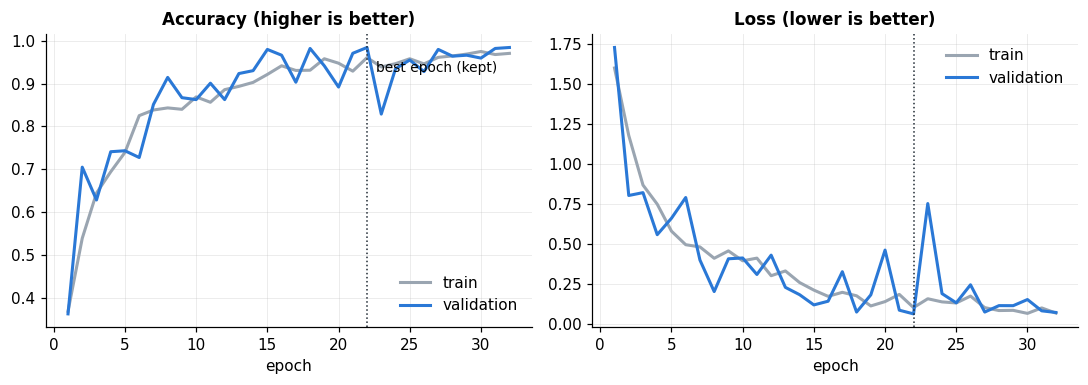

Train - validation accuracy gap at the kept epoch: -0.024


In [13]:
# =============================================================================
# FIGURE: TRAINING CURVES
# =============================================================================
ep = np.arange(1, epochs_run + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, k, title in [(axes[0], "accuracy", "Accuracy (higher is better)"),
                     (axes[1], "loss", "Loss (lower is better)")]:
    ax.plot(ep, h[k], color=MUTED, linewidth=2, label="train")
    ax.plot(ep, h[f"val_{k}"], color=MAIN, linewidth=2, label="validation")
    ax.axvline(best_epoch, color=INK, linewidth=1, linestyle=":")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend(frameon=False)
axes[0].annotate("best epoch (kept)", (best_epoch, h["val_accuracy"][best_epoch - 1]),
                 xytext=(6, -16), textcoords="offset points", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_training_curves.png"))
plt.show()

gap = h["accuracy"][best_epoch - 1] - h["val_accuracy"][best_epoch - 1]
print(f"Train - validation accuracy gap at the kept epoch: {gap:+.3f}")
if gap > 0.10:
    print("A large gap means overfitting: the model memorised training leaves. Report it.")

### Reading the curves

If training accuracy keeps rising while validation accuracy flattens, the model
is **memorising** the training leaves instead of learning what each plant looks
like. That's overfitting. The dotted line marks the epoch we kept.

Early on, training accuracy can sit *below* validation. Augmentation makes
training photos harder than the untouched validation photos. That's normal.

## Step 6 — The test set, once

Everything above used training and validation photos only. This is the first
and only time the model sees the test photos. These are the numbers you report.

In [14]:
# =============================================================================
# TEST-SET EVALUATION
# =============================================================================
P_va = model.predict(ds_va, verbose=0)
P_te = model.predict(ds_te, verbose=0)
pred_te = P_te.argmax(1)

acc = accuracy_score(y_te, pred_te)
macro_f1 = f1_score(y_te, pred_te, average="macro")
top2 = top_k_accuracy_score(y_te, P_te, k=2, labels=np.arange(NUM_CLASSES))
roc = roc_auc_score(y_te, P_te, multi_class="ovr", average="macro")
prec, rec, f1s, sup = precision_recall_fscore_support(y_te, pred_te, labels=np.arange(NUM_CLASSES),
                                                     zero_division=0)

print(f"TEST SET ({len(y_te):,} photos)\n")
print(f"  Accuracy          {acc:.4f}")
print(f"  Macro F1          {macro_f1:.4f}   <- headline: treats every plant equally")
print(f"  Top-2 accuracy    {top2:.4f}   (right answer in the model's first two guesses)")
print(f"  Macro ROC-AUC     {roc:.4f}\n")
per_class = pd.DataFrame({"precision": prec, "recall": rec, "F1": f1s, "test photos": sup},
                         index=CLASSES)
per_class.round(3)

TEST SET (332 photos)

  Accuracy          0.9699
  Macro F1          0.9560   <- headline: treats every plant equally
  Top-2 accuracy    0.9970   (right answer in the model's first two guesses)
  Macro ROC-AUC     0.9981



,precision,recall,F1,test photos
1,0.992,1.000,0.996,123
aloe_vera_bg,1.000,1.000,1.000,2
moringa_bg,1.000,0.982,0.991,55
nim_2_bg,0.975,0.929,0.952,85
nim_bg,0.750,1.000,0.857,9
tulsi_bg,0.932,0.948,0.940,58


### How to read these numbers

- **Accuracy**: the share of test photos named correctly.
- **Macro F1**: F1 computed for each plant separately, then averaged, so a rare
  plant counts as much as a common one. This is the headline number for
  comparing the four models.
- **Per-plant recall**: of all the real neem photos, how many were called neem?
- **Per-plant precision**: of all the photos called neem, how many really were?
- **Top-2 accuracy**: was the right plant at least the model's second guess?
  A high top-2 with lower accuracy means the model is close, and usually torn
  between two look-alike species.

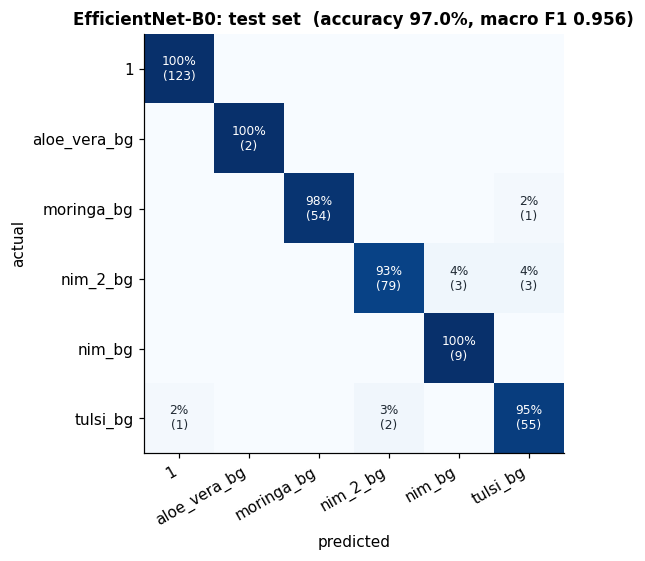

Most common mistake: nim_2_bg called nim_bg (3 photos)


In [15]:
# =============================================================================
# FIGURE: CONFUSION MATRIX (rows sum to 100%)
# =============================================================================
cm = confusion_matrix(y_te, pred_te, labels=np.arange(NUM_CLASSES))
cm_pct = cm / cm.sum(1, keepdims=True).clip(min=1) * 100

fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
ax.grid(False)
ax.set_xticks(range(NUM_CLASSES), CLASSES, rotation=30, ha="right")
ax.set_yticks(range(NUM_CLASSES), CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm[i, j]:
            ax.text(j, i, f"{cm_pct[i, j]:.0f}%\n({cm[i, j]})", ha="center", va="center",
                    fontsize=8, color="white" if cm_pct[i, j] > 55 else INK)
ax.set_title(f"{MODEL_NAME}: test set  (accuracy {acc:.1%}, macro F1 {macro_f1:.3f})")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_confusion.png"))
plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)
if off.sum():
    i, j = np.unravel_index(off.argmax(), off.shape)
    print(f"Most common mistake: {CLASSES[i]} called {CLASSES[j]} ({off[i, j]} photos)")

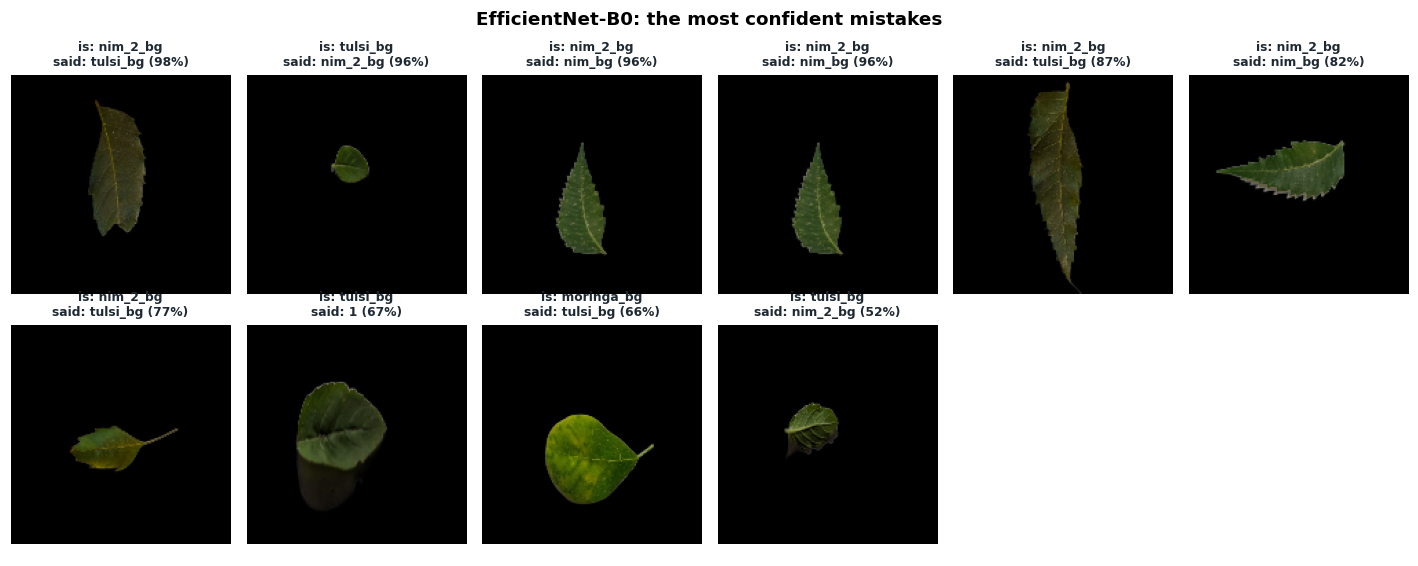

In [16]:
# =============================================================================
# FIGURE: WHAT DID IT GET WRONG?  (up to 12 misclassified test photos)
# =============================================================================
wrong = np.where(pred_te != y_te)[0]
if len(wrong) == 0:
    print("No test photo was misclassified.")
else:
    wrong = wrong[np.argsort(-P_te[wrong].max(1))][:12]    # most confident mistakes first
    cols = 6
    rows = int(np.ceil(len(wrong) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(13, 2.6 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, i in zip(axes, wrong):
        img = tf.io.decode_image(tf.io.read_file(te_df.loc[i, "path"]), channels=3,
                                 expand_animations=False)
        ax.imshow(tf.image.resize(img, (IMG_SIZE, IMG_SIZE)).numpy().astype("uint8"))
        ax.set_title(f"is: {CLASSES[y_te[i]]}\nsaid: {CLASSES[pred_te[i]]} ({P_te[i].max():.0%})",
                     fontsize=8, color=INK)
    plt.suptitle(f"{MODEL_NAME}: the most confident mistakes", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{TAG}_mistakes.png"))
    plt.show()

### Use this gallery in the report

Look for a pattern. Are the mistakes blurry? Photographed against a busy
background? Young leaves that don't yet look like the adult plant? A named
pattern is a far stronger discussion point than "the model made errors".

## Step 7 — The reject option: "I'm not sure"

On the collar, a wrong answer is worse than no answer. A goat eating a leaf that
gets **mislabelled** as neem puts a false record into the heritage database.

So the model only names a plant when its top probability reaches a threshold
**θ** (theta). Below that, it says *"not sure"* and the photo is kept for a
person to check. θ is chosen on **validation**: the lowest value at which the
answered photos are at least **98%** correct. Then it's applied to test.

The trade-off is **coverage**: the share of photos the model is willing to answer.

theta = 0.20  (lowest value giving >= 98% on validation)
On TEST: answers 100.0% of photos, and is right on 97.0% of those.
         the other 0.0% are passed to a person to check.


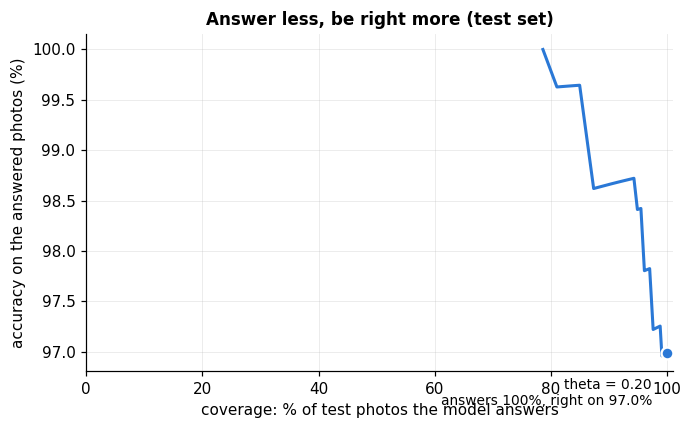

In [17]:
# =============================================================================
# REJECT THRESHOLD (chosen on validation) AND ITS EFFECT ON TEST
# =============================================================================
def coverage_curve(P, y, thetas):
    conf, pred = P.max(1), P.argmax(1)
    cov, accs = [], []
    for t in thetas:
        keep = conf >= t
        cov.append(keep.mean())
        accs.append((pred[keep] == y[keep]).mean() if keep.any() else np.nan)
    return np.array(cov), np.array(accs)


thetas = np.round(np.arange(0.20, 1.0, 0.01), 2)
cov_va, acc_va = coverage_curve(P_va, y_va, thetas)
ok = np.where((acc_va >= TARGET_ACCEPTED_ACCURACY) & (cov_va > 0))[0]
if len(ok):
    THETA = float(thetas[ok[0]])
    theta_note = f"lowest value giving >= {TARGET_ACCEPTED_ACCURACY:.0%} on validation"
else:
    # The target can't be reached. Take the most accurate theta that still
    # answers at least half of the validation photos.
    usable = np.where(cov_va >= 0.5)[0]
    THETA = float(thetas[usable[np.nanargmax(acc_va[usable])]])
    theta_note = (f"{TARGET_ACCEPTED_ACCURACY:.0%} was not reachable on validation; this is the most "
                  "accurate theta that still answers at least half the photos")

cov_te, acc_te = coverage_curve(P_te, y_te, thetas)
k = list(thetas).index(THETA)
reject = {"theta": THETA, "target_accuracy": TARGET_ACCEPTED_ACCURACY,
          "test_coverage": float(cov_te[k]),
          "test_accuracy_on_answered": (float(acc_te[k]) if cov_te[k] > 0 else None)}
reject["note"] = theta_note
print(f"theta = {THETA:.2f}  ({theta_note})")
if cov_te[k] > 0:
    print(f"On TEST: answers {cov_te[k]:.1%} of photos, and is right on {acc_te[k]:.1%} of those.")
else:
    print("On TEST: no photo reached theta, so the model answered none of them.")
print(f"         the other {1 - cov_te[k]:.1%} are passed to a person to check.")

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(cov_te * 100, acc_te * 100, color=MAIN, linewidth=2)
ax.set_xlim(0, 101)
ax.scatter([cov_te[k] * 100], [acc_te[k] * 100], s=60, color=MAIN, edgecolor="white",
           linewidth=1.5, zorder=3)
ax.annotate(f"theta = {THETA:.2f}\nanswers {cov_te[k]:.0%}" + (f", right on {acc_te[k]:.1%}" if cov_te[k] > 0 else ""),
            (cov_te[k] * 100, acc_te[k] * 100), xytext=(-10, -34), textcoords="offset points",
            fontsize=9, ha="right")
ax.set_xlabel("coverage: % of test photos the model answers")
ax.set_ylabel("accuracy on the answered photos (%)")
ax.set_title("Answer less, be right more (test set)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_reject_option.png"))
plt.show()

## Step 8 — Could it run on the collar?

We record the number of weights, the saved file size, the size after INT8
compression (one byte per weight), and the time to classify **one** photo at a
time on this laptop.

In [18]:
# =============================================================================
# SIZE AND SPEED
# =============================================================================
model.save(ckpt_path)
size_mb = os.path.getsize(ckpt_path) / 1e6

infer = tf.function(lambda x: model(x, training=False))
one = next(iter(ds_te))[0][:1]
for _ in range(5):
    infer(one)                                   # warm-up
t0 = time.time()
for _ in range(50):
    infer(one)
ms_per_image = 1000 * (time.time() - t0) / 50

print(f"Weights:          {N_PARAMS:,}")
print(f"Saved file:       {size_mb:.2f} MB  ({ckpt_path})")
print(f"INT8 estimate:    {N_PARAMS / 1e6:.3f} MB")
print(f"Speed:            {ms_per_image:.1f} ms per photo, one at a time, on this laptop")

Weights:          4,057,250
Saved file:       49.31 MB  (plant_results\models\M2_4_EfficientNetB0.keras)
INT8 estimate:    4.057 MB
Speed:            23.8 ms per photo, one at a time, on this laptop


In [19]:
# =============================================================================
# SAVE RESULTS  (the comparison notebook reads these)
# =============================================================================
results = {
    "model": MODEL_NAME,
    "tag": TAG,
    "family": "efficient network (MBConv blocks with squeeze-and-excitation)",
    "image_size": IMG_SIZE,
    "split_id": SPLIT_ID,
    "classes": CLASSES,
    "epochs_run": epochs_run,
    "best_epoch": best_epoch,
    "train_val_gap": float(gap),
    "test": {"accuracy": float(acc), "macro_f1": float(macro_f1), "top2_accuracy": float(top2),
             "macro_roc_auc": float(roc),
             "per_class": {c: {"precision": float(p), "recall": float(r), "f1": float(f)}
                           for c, p, r, f in zip(CLASSES, prec, rec, f1s)},
             "confusion_matrix": cm.tolist()},
    "reject_option": reject,
    "parameters": N_PARAMS,
    "model_size_mb": round(size_mb, 3),
    "int8_estimate_mb": round(N_PARAMS / 1e6, 3),
    "ms_per_image": round(ms_per_image, 2),
    "train_seconds": round(train_seconds, 1),
    "test_photos": int(len(y_te)),
}
json.dump(results, open(os.path.join(RESULTS_DIR, f"{TAG}.json"), "w"), indent=2)

# Per-photo test probabilities, for the confidence intervals in the comparison.
np.savez_compressed(os.path.join(RESULTS_DIR, f"{TAG}_test_probs.npz"),
                    probs=P_te, y=y_te, groups=te_df["group"].values.astype(str),
                    classes=np.array(CLASSES))
print(f"Saved: {os.path.join(RESULTS_DIR, TAG + '.json')}")
print(f"Test accuracy {acc:.4f}   macro F1 {macro_f1:.4f}   "
      f"coverage at theta {reject['test_coverage']:.1%}")

Saved: plant_results\results\M2_4_EfficientNetB0.json
Test accuracy 0.9699   macro F1 0.9560   coverage at theta 100.0%


## Scoreboard so far

Reads every plant-model results file in `plant_results/results/`, so the table
grows as you train the other three.

In [20]:
# =============================================================================
# SCOREBOARD: EVERY M2 MODEL TRAINED SO FAR
# =============================================================================
rows = []
for p in sorted(glob.glob(os.path.join(RESULTS_DIR, "M2_*.json"))):
    r = json.load(open(p))
    if "test" not in r:
        continue
    rows.append({"model": r["model"], "split ID": r.get("split_id"), "accuracy": r["test"]["accuracy"],
                 "macro F1": r["test"]["macro_f1"], "top-2": r["test"]["top2_accuracy"],
                 "coverage @theta": r["reject_option"]["test_coverage"],
                 "weights": r["parameters"], "INT8 MB": r["int8_estimate_mb"],
                 "ms/photo": r["ms_per_image"]})
pd.DataFrame(rows).set_index("model").round(4)

,split ID,accuracy,macro F1,top-2,coverage @theta,weights,INT8 MB,ms/photo
model,,,,,,,,
Simple CNN,2ee04fb978,0.9789,0.9260,1.000,1.0000,391398,0.391,9.40
ResNet-18,2ee04fb978,0.9669,0.9083,1.000,0.9729,11189190,11.189,32.87
MobileNetV2,2ee04fb978,0.9669,0.9116,0.997,0.9940,2265670,2.266,20.54
EfficientNet-B0,2ee04fb978,0.9699,0.9560,0.997,1.0000,4057250,4.057,23.76


---

## What to write in your report about this model

1. **Method.** Original photos only; near-identical shots grouped by perceptual
   hash and split 70/15/15 by group; 160 × 160 input;
   on-the-fly augmentation during training; the architecture above; class-weighted
   cross-entropy; Adam; early stopping on validation accuracy; trained from scratch.
2. **Result.** Test accuracy and macro F1, plus the per-plant table.
3. **Errors.** The most common confusion from the matrix, and the pattern you
   see in the mistakes gallery.
4. **Reject option.** θ, and the coverage and accuracy it gives on test.
5. **Deployability.** Weights, INT8 size and time per photo.

## Next

the comparison notebook, `M2_5_Compare_Models.ipynb`, which puts all four plant models side by side and chooses the one for the collar.